# DBSCAN Clustering on Customer Credit Card Data
This notebook preprocesses the data, runs DBSCAN, plots the K-distance graph to determine optimal epsilon, trains a KNN classifier proxy to handle predictions, and saves the pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
import joblib


In [2]:
df = pd.read_csv('CC GENERAL.csv')
X = df.drop(columns=['CUST_ID'])

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_scaled = preprocessor.fit_transform(X)


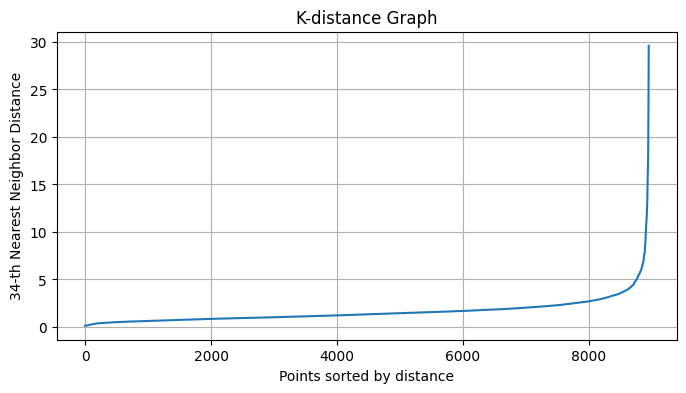

In [3]:
# Epsilon selection using K-distance graph (k = 2 * n_features = 34)
neighbors = NearestNeighbors(n_neighbors=34)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-distance Graph')
plt.xlabel('Points sorted by distance')
plt.ylabel('34-th Nearest Neighbor Distance')
plt.grid(True)
plt.show()


In [4]:
# Fit DBSCAN
db = DBSCAN(eps=2.5, min_samples=34)
labels = db.fit_predict(X_scaled)
print('Unique labels found:', np.unique(labels))
print('Noise percentage:', np.sum(labels == -1) / len(labels) * 100, '%')

# Train a KNN classifier on DBSCAN labels (treating noise -1 as a distinct class)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, labels)

# Final pipeline
dbscan_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', knn)
])
joblib.dump(dbscan_pipeline, 'dbscan_model.pkl')
print('DBSCAN Proxy Model Pipeline saved successfully!')


Unique labels found: [-1  0]
Noise percentage: 5.899441340782123 %
DBSCAN Proxy Model Pipeline saved successfully!
